# Remaining Useful Life (RUL) Prediction of Turbofan Engines
### Predictive maintenance on NASA C-MAPSS (FD001): LSTM benchmarked against XGBoost

**Author:** Ashok Choudhary | MS (Research), Applied Mechanics, IIT Madras

## Problem
Unplanned engine failures are costly and unsafe. If we can predict how many operating cycles an engine has left (its **Remaining Useful Life, RUL**), maintenance can be scheduled *before* failure instead of too early (wasted life) or too late (breakdown).

## Goal
Predict the RUL of each test engine at its **last recorded cycle** from multivariate sensor data, and compare classical ML baselines against a sequence model (LSTM).

## Summary of results
| Model | RMSE (cycles) | NASA score |
|---|---|---|
| XGBoost (baseline) | 20.11 | 1844.6 |
| **LSTM (5 seeds)** | **15.02 ± 0.18** | **~393** |

The LSTM reduces RMSE by about 25% and the asymmetric NASA score by about 79% versus XGBoost. Full results and limitations are at the end of this notebook.

## 1. Dataset
- **Source:** NASA C-MAPSS turbofan engine degradation simulation (Saxena et al., NASA Ames Prognostics Center of Excellence). Loaded here from a Hugging Face mirror: `SoyVitou/NASA-C-MAPSS-Turbofan-Engine`.
- **Subset used:** FD001 (one operating condition, one fault mode).
- **Structure:** each engine is a run-to-failure time series. 21 sensors + 3 operational settings are recorded at every cycle.
- **Size:** 100 training engines (20,631 rows) and 100 test engines (13,096 rows).
- **Test evaluation:** as in the original benchmark, the model is evaluated on the **last cycle of each test engine**, where the true RUL is known.

In [1]:
!pip install datasets -q
from datasets import load_dataset
import pandas as pd

ds = load_dataset("SoyVitou/NASA-C-MAPSS-Turbofan-Engine", "FD001")
print(ds)

train = ds["train"].to_pandas()
test  = ds["test"].to_pandas()
print(train.shape, test.shape)
train.head()

README.md: 0.00B [00:00, ?B/s]

processed/FD001/train.parquet:   0%|          | 0.00/535k [00:00<?, ?B/s]

processed/FD001/test.parquet:   0%|          | 0.00/351k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20631 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/13096 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['unit_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32', 'RUL', 'dataset', 'split'],
        num_rows: 20631
    })
    test: Dataset({
        features: ['unit_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32', 'RUL', 'dataset', 'split'],
        num_rows: 13096
    })
})
(20631, 29) (13096, 29)


,unit_id,cycle,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32,RUL,dataset,split
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8.4195,0.03,392,2388,100.0,39.06,23.4190,191,FD001,train
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8.4318,0.03,392,2388,100.0,39.00,23.4236,190,FD001,train
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8.4178,0.03,390,2388,100.0,38.95,23.3442,189,FD001,train
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8.3682,0.03,392,2388,100.0,38.88,23.3739,188,FD001,train
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8.4294,0.03,393,2388,100.0,38.90,23.4044,187,FD001,train


## 2. Exploratory Data Analysis
Checks performed below:
- Number of engines and the distribution of engine life
- Missing values
- Constant (zero-variance) columns
- How RUL is given in the test set
- Sensor trends against cycle, for a few engines
- Correlation of each sensor with RUL

In [2]:
# 1. Kitne engines, aur har engine ki life
print("Train engines:", train['unit_id'].nunique())
print("Test engines :", test['unit_id'].nunique())

life = train.groupby('unit_id')['cycle'].max()
print(life.describe())

# 2. Missing values
print("Missing values:", train.isnull().sum().sum())

# 3. Constant columns (std = 0) -> inhe baad me hataenge
feature_cols = [c for c in train.columns if c not in ['unit_id','cycle','RUL','dataset','split']]
stds = train[feature_cols].std()
const_cols = stds[stds < 1e-6].index.tolist()
print("Constant columns:", const_cols)

# 4. Test me RUL kaise diya hai? (last cycle par check)
last_test = test.groupby('unit_id').tail(1)[['unit_id','cycle','RUL']]
print(last_test.head(10))
print("Test RUL min/max:", test['RUL'].min(), test['RUL'].max())

Train engines: 100
Test engines : 100
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64
Missing values: 0
Constant columns: ['setting_3', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
      unit_id  cycle  RUL
30          1     31  112
79          2     49   98
205         3    126   69
311         4    106   82
409         5     98   91
514         6    105   93
674         7    160   91
840         8    166   95
895         9     55  111
1087       10    192   96
Test RUL min/max: 7 340


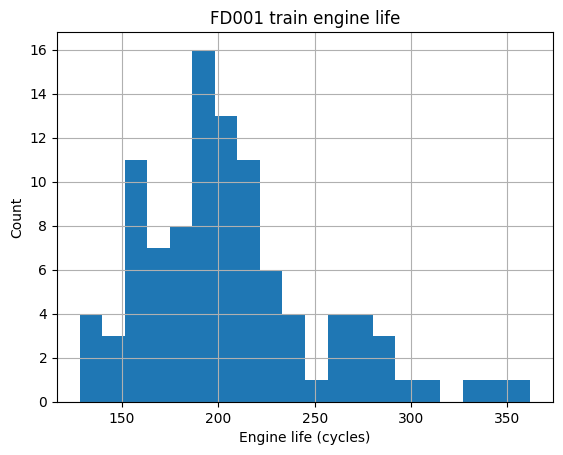

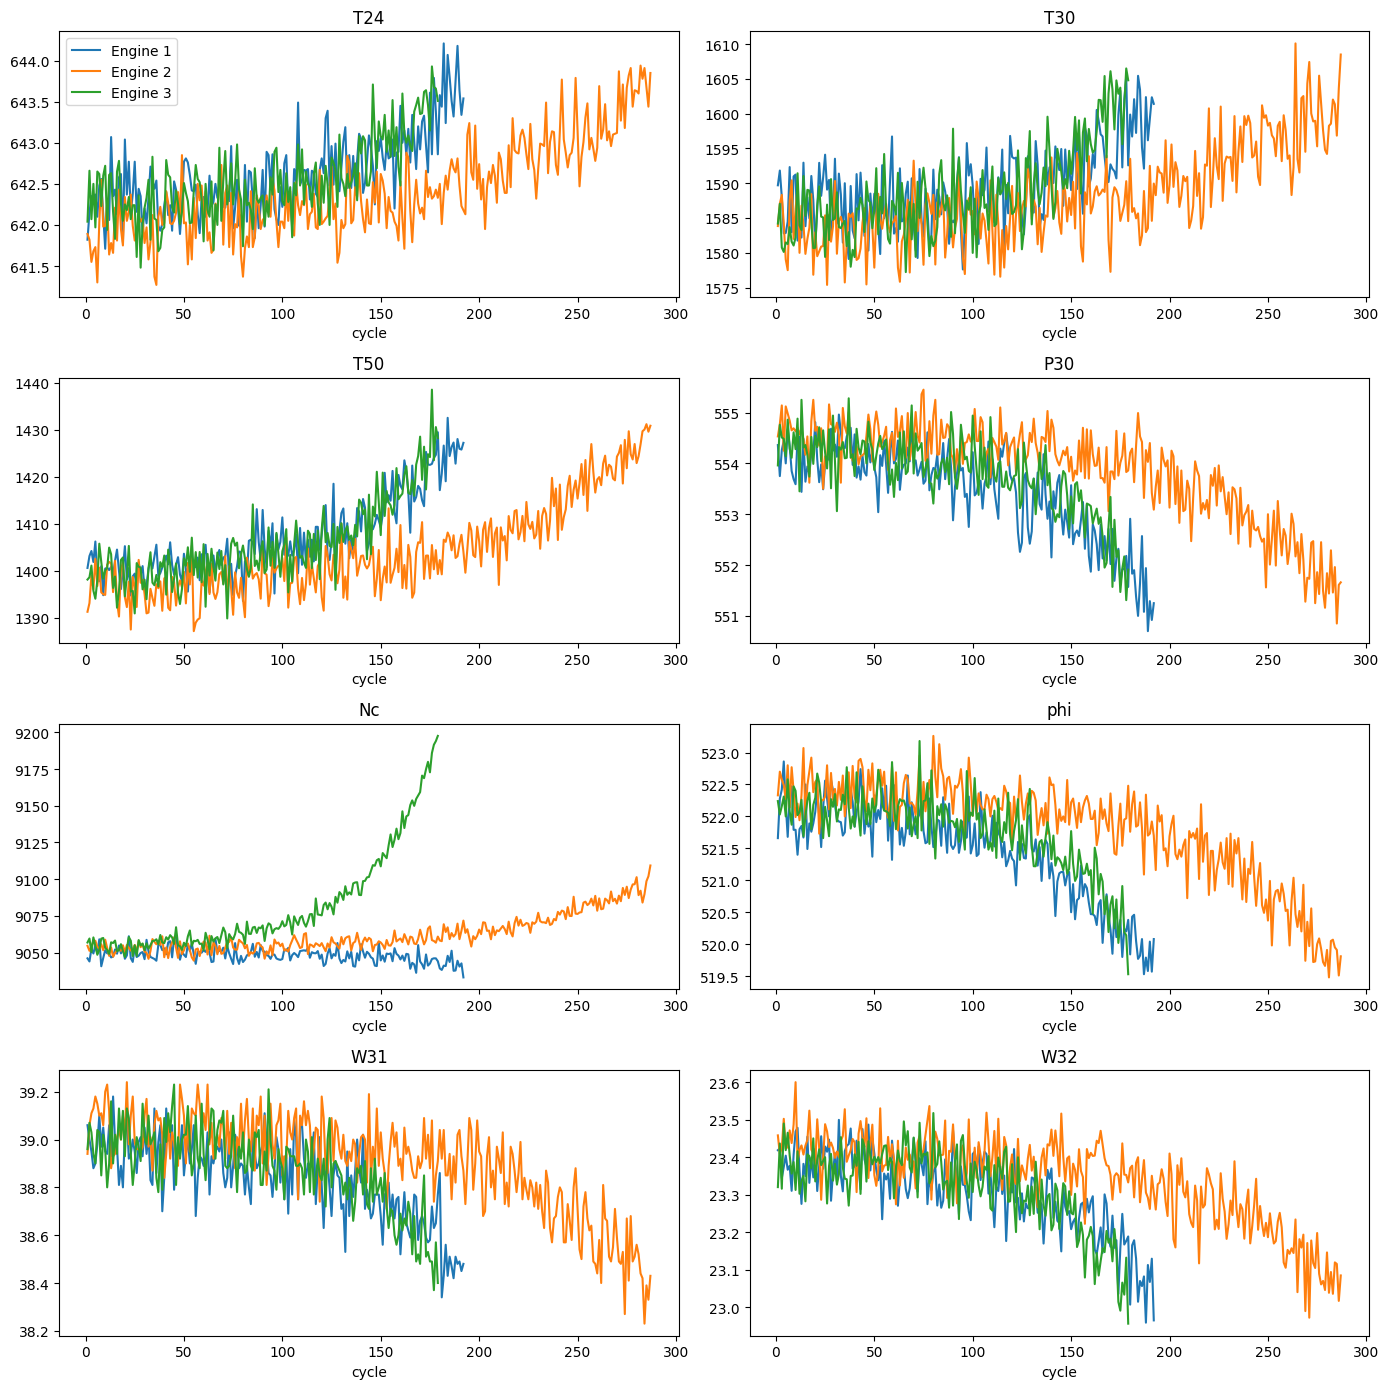

In [3]:
import matplotlib.pyplot as plt

# Engine life histogram
life.hist(bins=20)
plt.xlabel("Engine life (cycles)"); plt.ylabel("Count"); plt.title("FD001 train engine life")
plt.show()

# Kuch useful sensors, 3 engines ke liye
sensors = ['T24','T30','T50','P30','Nc','phi','W31','W32']
engines = [1, 2, 3]

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
for ax, s in zip(axes.ravel(), sensors):
    for e in engines:
        d = train[train.unit_id == e]
        ax.plot(d['cycle'], d[s], label=f"Engine {e}")
    ax.set_title(s); ax.set_xlabel("cycle")
axes[0,0].legend()
plt.tight_layout(); plt.show()

Ps30        -0.696228
T50         -0.678948
BPR         -0.642667
T24         -0.606484
htBleed     -0.606154
T30         -0.584520
Nf          -0.563968
NRf         -0.562569
Nc          -0.390102
NRc         -0.306769
P15         -0.128348
setting_1   -0.003198
setting_2   -0.001948
W31          0.629428
W32          0.635662
P30          0.657223
phi          0.671983
Name: RUL, dtype: float64


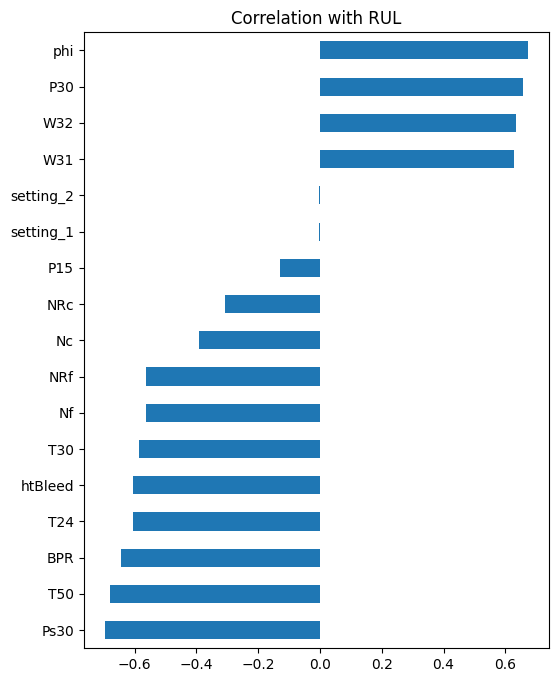

In [4]:
useful = [c for c in feature_cols if c not in const_cols]
corr = train[useful + ['RUL']].corr()['RUL'].drop('RUL').sort_values()
print(corr)
corr.plot(kind='barh', figsize=(6,8)); plt.title("Correlation with RUL"); plt.show()

### Key observations from EDA
- **Engine life varies a lot:** 128 to 362 cycles (mean about 206). Each engine degrades at its own pace.
- **No missing values**, but **7 columns are constant** (`setting_3, T2, P2, epr, farB, Nf_dmd, PCNfR_dmd`) and carry no information.
- **Degradation is visible in several sensors:** `T24`, `T30`, `T50` (temperatures) and `Nc` drift upward, while `P30`, `phi`, `W31`, `W32` drift downward as the engine wears.
- **Engines stay healthy for roughly the first 100 cycles**, then degradation becomes visible. So predicting RUL far from failure is inherently hard, and RUL is **capped at 125 cycles** for training (a standard practice for this dataset).
- **Sensor noise is high**, so a single cycle is a weak signal. This motivates using a window of past cycles.
- **Weak features:** `setting_1`, `setting_2` (correlation about 0) and `P15` (about -0.13) are dropped.
- **Strongest correlations with RUL:** `Ps30` (-0.70), `phi` (+0.67), `T50` (-0.68), `P30` (+0.66). Different engines show different patterns (e.g. `Nc`), which suggests fault evolution is not identical across engines.

**Sensors kept (14):** T24, T30, T50, P30, Nf, Nc, Ps30, phi, NRf, NRc, BPR, htBleed, W31, W32.

## 3. Preprocessing and baseline models
**Preprocessing**
1. Drop constant and weak columns (14 sensors remain).
2. **Cap the training RUL at 125** so the model does not try to predict degradation during the healthy phase.
3. Min-max scale sensors. The scaler is **fit on training data only** to avoid leakage.
4. Add 10-cycle **rolling-mean** features per engine (uses only past cycles).

**Metrics**
- **RMSE** in cycles.
- **NASA scoring function**, which penalises *late* predictions (predicting more life than the engine has) more heavily than early ones. This matches the real cost in maintenance, where a late prediction is more dangerous.
- Since test labels are uncapped, results are reported for both raw and capped (125) test labels.

**Baselines:** Linear Regression, Random Forest, XGBoost, each using a single cycle's features plus rolling means.

In [5]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Bekaar columns hatao
drop_cols = ['setting_1','setting_2','setting_3','T2','P2','P15','epr','farB','Nf_dmd','PCNfR_dmd']
sensors = [c for c in feature_cols if c not in drop_cols]
print(len(sensors), sensors)

# 2. RUL cap (sirf training target par)
CAP = 125
train['RUL_cap'] = train['RUL'].clip(upper=CAP)

# 3. Scaling: sirf train par fit, test par sirf transform
scaler = MinMaxScaler().fit(train[sensors])
train_s, test_s = train.copy(), test.copy()
train_s[sensors] = scaler.transform(train[sensors])
test_s[sensors]  = scaler.transform(test[sensors])

# 4. Rolling mean features (har engine ke andar, sirf peeche ke cycles use hote hain)
def add_rolling(df, cols, w=10):
    df = df.sort_values(['unit_id','cycle']).copy()
    roll = (df.groupby('unit_id')[cols].rolling(w, min_periods=1).mean()
              .reset_index(level=0, drop=True))
    roll.columns = [c + '_rm' for c in cols]
    return pd.concat([df, roll], axis=1)

train_f = add_rolling(train_s, sensors)
test_f  = add_rolling(test_s, sensors)
features = sensors + [c + '_rm' for c in sensors]

X_train, y_train = train_f[features], train_f['RUL_cap']

# 5. Test: har engine ka sirf last cycle
test_last = test_f.groupby('unit_id').tail(1)
X_test, y_true = test_last[features], test_last['RUL']

# 6. Metrics: RMSE aur NASA score
def nasa_score(y_true, y_pred):
    d = np.asarray(y_pred) - np.asarray(y_true)
    return np.sum(np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1))

def evaluate(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    print(f"{name:18s} RMSE = {rmse:6.2f} | NASA score = {nasa_score(y_true, pred):9.1f}")
    return pred

pred_lr = evaluate("LinearRegression", LinearRegression())
pred_rf = evaluate("RandomForest", RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42))

14 ['T24', 'T30', 'T50', 'P30', 'Nf', 'Nc', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32']
LinearRegression   RMSE =  21.80 | NASA score =    1576.1
RandomForest       RMSE =  21.08 | NASA score =    1976.1


### Baseline results (last cycle of each test engine)
| Model | RMSE (raw) | RMSE (capped) | NASA score (capped) |
|---|---|---|---|
| Linear Regression | 21.80 | 20.81 | 1523.9 |
| Random Forest | 21.08 | 20.12 | 1935.4 |
| XGBoost | 20.11 | 19.15 | 1844.6 |

All three baselines land between 19 and 22 RMSE. The predicted-vs-actual plot below shows **spiky predictions**, e.g. engines with true RUL around 15 to 20 predicted as 75 to 85. Because each prediction sees only one cycle (plus a short rolling mean), sensor noise leaks straight into the output. A model that looks at the **trend over many cycles** should do better.

XGBoost            RMSE =  20.11 | NASA score =    1879.8

--- Summary ---
LinearRegression   RMSE(raw)= 21.80 | RMSE(capped)= 20.81 | NASA(capped)=   1523.9
RandomForest       RMSE(raw)= 21.08 | RMSE(capped)= 20.12 | NASA(capped)=   1935.4
XGBoost            RMSE(raw)= 20.11 | RMSE(capped)= 19.15 | NASA(capped)=   1844.6


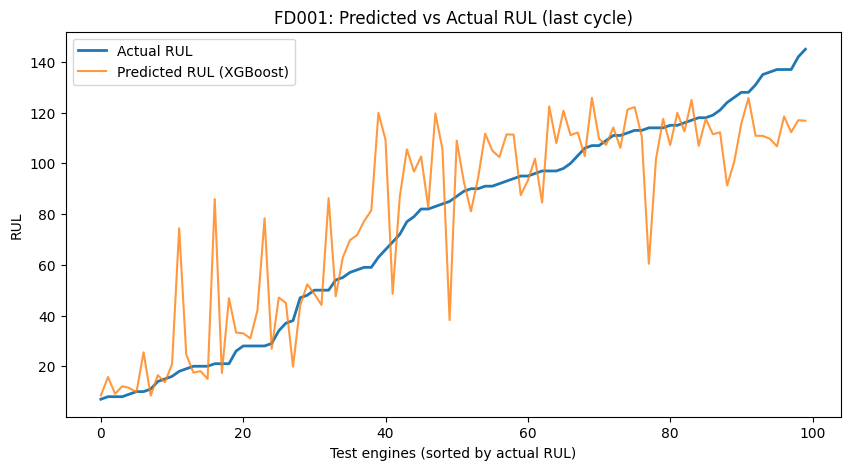

In [6]:
!pip install xgboost -q
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

y_true_cap = y_true.clip(upper=CAP)

def report(name, pred):
    r1 = np.sqrt(mean_squared_error(y_true, pred))
    r2 = np.sqrt(mean_squared_error(y_true_cap, pred))
    print(f"{name:18s} RMSE(raw)={r1:6.2f} | RMSE(capped)={r2:6.2f} | NASA(capped)={nasa_score(y_true_cap, pred):9.1f}")

pred_xgb = evaluate("XGBoost", XGBRegressor(n_estimators=400, learning_rate=0.05,
                                            max_depth=5, subsample=0.8,
                                            colsample_bytree=0.8, random_state=42))

print("\n--- Summary ---")
report("LinearRegression", pred_lr)
report("RandomForest", pred_rf)
report("XGBoost", pred_xgb)

# Predicted vs Actual (best model ke liye, yahan XGBoost)
order = np.argsort(y_true.values)
plt.figure(figsize=(10,5))
plt.plot(y_true.values[order], label="Actual RUL", lw=2)
plt.plot(pred_xgb[order], label="Predicted RUL (XGBoost)", alpha=0.8)
plt.xlabel("Test engines (sorted by actual RUL)"); plt.ylabel("RUL")
plt.legend(); plt.title("FD001: Predicted vs Actual RUL (last cycle)")
plt.show()

## 4. LSTM model
**Approach**
- Each sample is a **sliding window of the last 30 cycles** x 14 sensors. Engines with fewer than 30 cycles at the start are padded by repeating the first row.
- Model: 2-layer LSTM (64 hidden units, dropout 0.2) followed by a small fully connected head, predicting RUL (scaled by 125).
- Loss: MSE. Optimiser: Adam (lr 1e-3), 40 epochs.

**Validation (no test leakage)**
- 20 of the 100 training engines are held out as a **validation set, split by engine** (not by row), so windows from the same engine never appear in both train and validation.
- The **best epoch is chosen on validation RMSE**. The test set is used only once, for the final evaluation.

In [7]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42); np.random.seed(42)
W = 30

def make_windows(df, cols, w=W, last_only=False, target='RUL_cap'):
    Xs, ys, ids = [], [], []
    for uid, g in df.sort_values(['unit_id','cycle']).groupby('unit_id'):
        arr = g[cols].values.astype(np.float32)
        pad = np.vstack([np.repeat(arr[:1], w-1, axis=0), arr])  # shuru me padding
        idx = [len(arr)-1] if last_only else range(len(arr))
        for i in idx:
            Xs.append(pad[i:i+w])
            ids.append(uid)
            if target in g.columns:
                ys.append(g[target].values[i])
    return np.array(Xs), np.array(ys, dtype=np.float32), np.array(ids)

X_all, y_all, id_all = make_windows(train_s, sensors)
X_te, _, _ = make_windows(test_s, sensors, last_only=True)
print(X_all.shape, X_te.shape)   # (20631, 30, 14), (100, 30, 14)

# Engine-wise train/validation split (20 engines validation ke liye)
units = np.random.permutation(train_s['unit_id'].unique())
val_units = units[:20]
is_val = np.isin(id_all, val_units)
X_tr, y_tr = X_all[~is_val], y_all[~is_val]
X_va, y_va = X_all[is_val],  y_all[is_val]

def loader(X, y, shuffle):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y / CAP))
    return DataLoader(ds, batch_size=256, shuffle=shuffle)

tr_dl, va_dl = loader(X_tr, y_tr, True), loader(X_va, y_va, False)

class RULNet(nn.Module):
    def __init__(self, n_feat, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, num_layers=2, batch_first=True, dropout=0.2)
        self.head = nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1]).squeeze(-1)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = RULNet(len(sensors)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

def predict(m, X):
    m.eval()
    with torch.no_grad():
        return m(torch.tensor(X).to(device)).cpu().numpy() * CAP

best_val, best_state = 1e9, None
for epoch in range(40):
    model.train()
    for xb, yb in tr_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss_fn(model(xb), yb).backward()
        opt.step()
    val_rmse = np.sqrt(np.mean((predict(model, X_va) - y_va) ** 2))
    if val_rmse < best_val:
        best_val = val_rmse
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch+1:2d} | val RMSE = {val_rmse:.2f}")

model.load_state_dict(best_state)
pred_lstm = predict(model, X_te)

print("\n--- Test (last cycle per engine) ---")
report("XGBoost", pred_xgb)
report("LSTM", pred_lstm)

(20631, 30, 14) (100, 30, 14)
epoch  5 | val RMSE = 13.69
epoch 10 | val RMSE = 12.73
epoch 15 | val RMSE = 12.05
epoch 20 | val RMSE = 11.86
epoch 25 | val RMSE = 11.66
epoch 30 | val RMSE = 11.46
epoch 35 | val RMSE = 12.12
epoch 40 | val RMSE = 11.74

--- Test (last cycle per engine) ---
XGBoost            RMSE(raw)= 20.11 | RMSE(capped)= 19.15 | NASA(capped)=   1844.6
LSTM               RMSE(raw)= 14.52 | RMSE(capped)= 13.30 | NASA(capped)=    319.8


## 5. Robustness: multiple random seeds
A single training run can be lucky. To get an honest estimate, the LSTM is trained with **5 different random seeds**, and the **mean and standard deviation** are reported, not the best run. An **ensemble** (average of the 5 models' predictions) is also evaluated.

seed 0: RMSE(raw)=15.21 | RMSE(capped)=14.15 | NASA(capped)=434.9
seed 1: RMSE(raw)=14.91 | RMSE(capped)=13.76 | NASA(capped)=369.7
seed 2: RMSE(raw)=15.03 | RMSE(capped)=14.03 | NASA(capped)=409.7
seed 3: RMSE(raw)=15.20 | RMSE(capped)=14.06 | NASA(capped)=410.7
seed 4: RMSE(raw)=14.75 | RMSE(capped)=13.53 | NASA(capped)=338.7

LSTM over 5 seeds: RMSE(raw) = 15.02 ± 0.18 | RMSE(capped) = 13.91 ± 0.23
LSTM ensemble      RMSE(raw)= 14.87 | RMSE(capped)= 13.74 | NASA(capped)=    381.7


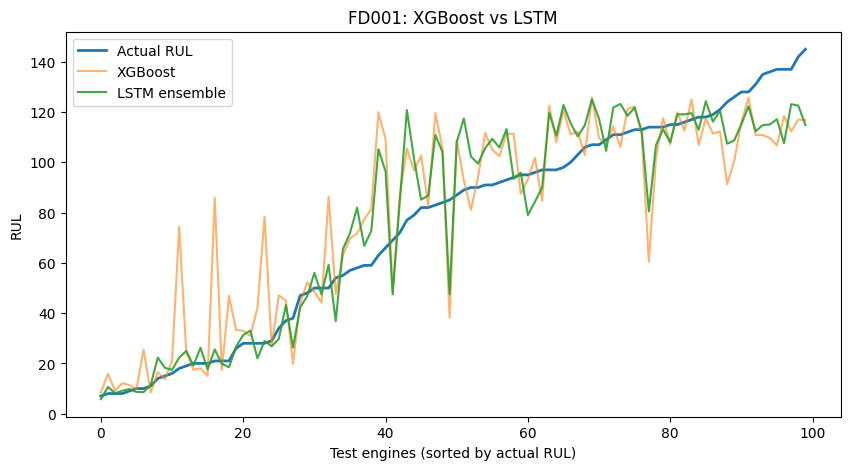

In [8]:
def train_model(seed, epochs=40):
    torch.manual_seed(seed); np.random.seed(seed)
    m = RULNet(len(sensors)).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    best_v, best_s = 1e9, None
    for ep in range(epochs):
        m.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss_fn(m(xb), yb).backward(); opt.step()
        v = np.sqrt(np.mean((predict(m, X_va) - y_va) ** 2))
        if v < best_v:
            best_v, best_s = v, {k: t.clone() for k, t in m.state_dict().items()}
    m.load_state_dict(best_s)
    return m

seeds = [0, 1, 2, 3, 4]
preds = []
for s in seeds:
    p = predict(train_model(s), X_te)
    preds.append(p)
    print(f"seed {s}: RMSE(raw)={np.sqrt(mean_squared_error(y_true, p)):.2f} | "
          f"RMSE(capped)={np.sqrt(mean_squared_error(y_true_cap, p)):.2f} | "
          f"NASA(capped)={nasa_score(y_true_cap, p):.1f}")

preds = np.array(preds)
raw = [np.sqrt(mean_squared_error(y_true, p)) for p in preds]
cap = [np.sqrt(mean_squared_error(y_true_cap, p)) for p in preds]
print(f"\nLSTM over {len(seeds)} seeds: RMSE(raw) = {np.mean(raw):.2f} ± {np.std(raw):.2f} | "
      f"RMSE(capped) = {np.mean(cap):.2f} ± {np.std(cap):.2f}")

pred_ens = preds.mean(axis=0)
report("LSTM ensemble", pred_ens)

# Predicted vs Actual plot
order = np.argsort(y_true.values)
plt.figure(figsize=(10,5))
plt.plot(y_true.values[order], label="Actual RUL", lw=2)
plt.plot(pred_xgb[order], label="XGBoost", alpha=0.6)
plt.plot(pred_ens[order], label="LSTM ensemble", alpha=0.9)
plt.xlabel("Test engines (sorted by actual RUL)"); plt.ylabel("RUL")
plt.legend(); plt.title("FD001: XGBoost vs LSTM")
plt.show()

## 6. Results

| Model | RMSE (raw) | RMSE (capped) | NASA score (capped) |
|---|---|---|---|
| Linear Regression | 21.80 | 20.81 | 1523.9 |
| Random Forest | 21.08 | 20.12 | 1935.4 |
| XGBoost | 20.11 | 19.15 | 1844.6 |
| **LSTM (mean of 5 seeds)** | **15.02 ± 0.18** | **13.91 ± 0.23** | **~393** |
| LSTM ensemble (5 seeds) | 14.87 | 13.74 | 381.7 |

**Improvement of LSTM over XGBoost:** about 25% lower RMSE (raw), 27% lower RMSE (capped), and about 79% lower NASA score.

### What the plot shows
- **Near failure (RUL 0 to 35), the LSTM is much smoother and more accurate** than XGBoost. The large spikes seen with XGBoost disappear. This is the most important region, because it drives maintenance decisions.
- The large drop in NASA score means far fewer dangerous *late* predictions.
- Seed-to-seed variation is small (std 0.18 RMSE), so the model is stable.

## 7. Limitations
- **Mid-range outliers:** for some engines (true RUL roughly 40 to 80), the predicted RUL drops sharply. These are likely engines with unusual sensor noise or trends, and were not analysed in depth.
- **Capping at 125:** RUL above 125 is underestimated by design. This is standard for this benchmark but means the model says little about engines very far from failure.
- **Only FD001** (single operating condition) was evaluated. FD002 and FD004 (six operating conditions) are harder and not yet tested.
- **No hyperparameter search:** window size, hidden size, dropout and learning rate were not tuned systematically.
- Validation uses only 20 engines, so it is a noisy estimate.

## 8. Future work
- Try a 1D-CNN or CNN-LSTM, and longer windows (e.g. 50 cycles).
- Add a **physics-informed constraint** (RUL should not increase with time) to reduce the sudden drops.
- Extend to FD002, FD003 and FD004, with operating-condition-aware normalisation.
- Build a small dashboard that shows predicted RUL and health trend per engine.

## References
- A. Saxena, K. Goebel, D. Simon, N. Eklund, "Damage Propagation Modeling for Aircraft Engine Run-to-Failure Simulation," PHM 2008.
- NASA Prognostics Center of Excellence, C-MAPSS dataset.